In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')

Not running on Colab — skipping drive.mount.


In [3]:
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'

In [4]:
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                         if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes   = len(label_encoder)
print(f'{num_classes} classes from folder structure.')

52 classes from folder structure.


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


## Feature extraction — 8 views, summary + patch tokens

**Experiment #2** — rotational TTA: adds 90 ° and 270 ° views (coins are rotationally invariant).

**Experiment #3** — patch tokens: RADIO returns `(summary, spatial)`. We mean-pool `spatial` to get a second 2560-d vector and concatenate it with `summary`, giving a **5120-d** feature per image that encodes both global identity and local texture/legend detail.

**Experiment #9** — r512 view: sharper at 512 px, helps with fine legend text.

Each chunk is saved with both `features_summary` and `features_patch`; the cell is fully resumable.

In [6]:
image_dir  = Path(DATA_DIR)
filepaths  = sorted(image_dir.glob('*/side_a/*.jpg'))
raw_labels = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int = [label_encoder[l] for l in raw_labels]
print(f'Total images: {len(filepaths)}')

# (name, resolution, h_flip, rotation_degrees)
VIEWS = [
    ('r256',      256, False,   0),
    ('r256_flip', 256, True,    0),
    ('r256_r90',  256, False,  90),   # exp #2: rotational TTA
    ('r256_r270', 256, False, 270),   # exp #2
    ('r384',      384, False,   0),
    ('r384_flip', 384, True,    0),
    ('r384_r90',  384, False,  90),   # exp #2
    ('r512',      512, False,   0),   # exp #9: high-res view
]
NUM_CHUNKS    = 10
EXTRACT_BATCH = 8

tta_root   = Path(DATA_DIR) / 'cradio_v4b_tta_chunks'
final_path = Path(DATA_DIR) / 'cradio_v4b_embeddings.pt'
tta_root.mkdir(parents=True, exist_ok=True)


def chunk_ranges(n_total, n_chunks):
    edges = np.linspace(0, n_total, n_chunks + 1, dtype=int)
    return [(i, int(edges[i]), int(edges[i + 1])) for i in range(n_chunks)]


class CoinDataset(Dataset):
    def __init__(self, fps, labs, resolution, flip, rotation):
        self.fps = fps; self.labs = labs
        self.resolution = resolution; self.flip = flip; self.rotation = rotation

    def __len__(self): return len(self.fps)

    def __getitem__(self, i):
        img = Image.open(self.fps[i]).convert('RGB')
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        if self.flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        if self.rotation:
            img = img.rotate(self.rotation, expand=False)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


@torch.no_grad()
def run_chunk(model, sub_fp, sub_lb, resolution, flip, rotation):
    ds     = CoinDataset(sub_fp, sub_lb, resolution, flip, rotation)
    loader = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
    sums, patches, labs = [], [], []
    for j, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, spatial = model(imgs)          # spatial: (B, num_patches, D)
        sums.append(summary.float().cpu())
        patches.append(spatial.float().mean(dim=1).cpu())   # mean-pool patches
        labs.append(l)
        if (j + 1) % 100 == 0:
            print(f'      batch {j + 1}/{len(loader)}')
    return torch.cat(sums), torch.cat(patches), torch.cat(labs)


ranges = chunk_ranges(len(filepaths), NUM_CHUNKS)

if final_path.exists():
    print(f'Final embeddings already exist at {final_path} — skipping extraction.')
else:
    missing = [
        (vname, res, flip, rot, idx, s, e, tta_root / f'{vname}_chunk_{idx:02d}.pt')
        for vname, res, flip, rot in VIEWS
        for idx, s, e in ranges
        if not (tta_root / f'{vname}_chunk_{idx:02d}.pt').exists()
    ]

    if not missing:
        print('All chunks already on disk — skipping backbone load.')
    else:
        print(f'{len(missing)}/{len(VIEWS) * NUM_CHUNKS} chunks remaining. Loading C-RADIO v4-H...')
        radio_model = torch.hub.load('NVlabs/RADIO', 'radio_model',
                                     version='c-radio_v4-h', progress=True)
        radio_model = radio_model.to(device).eval()
        for p in radio_model.parameters():
            p.requires_grad = False

        for vname, res, flip, rot, idx, start, end, out_path in missing:
            print(f'  view={vname}  chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}')
            t0     = datetime.now()
            sub_fp = [str(p) for p in filepaths[start:end]]
            sub_lb = labels_int[start:end]
            s_f, p_f, labs = run_chunk(radio_model, sub_fp, sub_lb, res, flip, rot)
            torch.save({'features_summary': s_f, 'features_patch': p_f, 'labels': labs},
                       out_path)
            print(f'    saved {out_path.name}  in {datetime.now() - t0}')

        del radio_model
        torch.cuda.empty_cache()

    print('Concatenating + averaging across views...')
    sum_s = None; sum_p = None; label_tensor = None
    for vname, *_ in VIEWS:
        v_s, v_p, v_l = [], [], []
        for idx, *_ in ranges:
            d = torch.load(tta_root / f'{vname}_chunk_{idx:02d}.pt')
            v_s.append(d['features_summary'])
            v_p.append(d['features_patch'])
            v_l.append(d['labels'])
        vs = torch.cat(v_s); vp = torch.cat(v_p)
        sum_s = vs if sum_s is None else sum_s + vs
        sum_p = vp if sum_p is None else sum_p + vp
        if label_tensor is None:
            label_tensor = torch.cat(v_l)

    avg_s    = sum_s / len(VIEWS)
    avg_p    = sum_p / len(VIEWS)
    combined = torch.cat([avg_s, avg_p], dim=-1)   # (N, 5120)
    torch.save({'features': combined, 'labels': label_tensor}, final_path)
    print(f'Saved combined embeddings → {final_path}  shape={combined.shape}')

Total images: 62134
Final embeddings already exist at /home/david/coin/FOR_TRAINNING/cradio_v4b_embeddings.pt — skipping extraction.


In [7]:
saved = torch.load(final_path)
all_feats, all_labs = saved['features'], saved['labels']
print(f'V4 embeddings: {all_feats.shape}')   # (62134, 5120)

V4 embeddings: torch.Size([62134, 3840])


In [8]:
MERGES = {'GORDIAN II': 'GORDIAN I'}

remap  = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names        = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new        = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs      = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'After merge: {num_classes} classes.')

After merge: 51 classes.


In [9]:
train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

print(f'Train: {train_feats.shape[0]}  Val: {val_feats.shape[0]}  Test: {test_feats.shape[0]}')
print(f'Feature dim: {train_feats.shape[1]}')

class_counts = torch.bincount(train_labs, minlength=num_classes).float()
beta         = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights   = (1.0 - beta) / effective_num
cb_weights   = cb_weights / cb_weights.sum() * num_classes
cb_weights   = cb_weights.to(device)
print('Class-balanced weights ready.')

Train: 39765  Val: 9942  Test: 12427
Feature dim: 3840
Class-balanced weights ready.


In [10]:
batch_size     = 512
sample_weights = cb_weights.cpu()[train_labs]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_labs), replacement=True)
train_loader   = DataLoader(TensorDataset(train_feats, train_labs),
                             batch_size=batch_size, sampler=train_sampler)
val_loader     = DataLoader(TensorDataset(val_feats,   val_labs),   batch_size=batch_size, shuffle=False)
test_loader    = DataLoader(TensorDataset(test_feats,  test_labs),  batch_size=batch_size, shuffle=False)
print('Loaders ready.')

Loaders ready.


In [11]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((name_to_prefix.get(name, 99), name,
                 int(train_c.get(cls_idx, 0)),
                 int(val_c.get(cls_idx, 0)),
                 int(test_c.get(cls_idx, 0))))
rows.sort()
per_class_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
per_class_counts['Total'] = per_class_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(per_class_counts.to_string(index=False))

 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1074  269   336   1679
 2          TIBERIUS    527  132   165    824
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    882  221   276   1379
 5              NERO    926  232   290   1448
 6             GALBA    991  248   310   1549
 7              OTHO    411  103   129    643
 8         VITELLIUS    568  142   178    888
 9         VESPASIAN   1361  340   425   2126
10             TITUS   1121  280   350   1751
11          DOMITIAN   1309  327   409   2045
12             NERVA   1105  276   345   1726
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   245   1227
18          COMMODUS   1122  281   351   1754
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   158    792
21  SEPTIMUS SEVERUS   1501  375  

## Model — ArcFace classifier + wider head

**Experiment #4** — ArcFace loss: adds a fixed angular margin `m` to the target class angle before softmax, forcing the model to learn tighter, more separated clusters in embedding space.

**Experiment #11** — Ensemble diversity: each of the 10 heads uses a slightly different hidden size / dropout / mixup-alpha, so the ensemble members make different errors and the average is more robust.

In [12]:
class ArcFaceClassifier(nn.Module):
    """Cosine classifier with additive angular margin.

    margin=0.2 is intentionally mild so it stays compatible with mixup.
    scale=20 matches v3's CosineClassifier range.
    """
    def __init__(self, in_dim, n_cls, scale=20.0, margin=0.2):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim))
        nn.init.xavier_uniform_(self.weight)
        self.scale  = scale
        self.margin = margin

    def forward(self, x, labels=None):
        x   = F.normalize(x, dim=-1)
        w   = F.normalize(self.weight, dim=-1)
        cos = x @ w.T                                          # (B, C)
        if labels is None or not self.training:
            return self.scale * cos
        theta      = cos.clamp(-1 + 1e-7, 1 - 1e-7).acos()
        target_cos = (theta + self.margin).cos()
        one_hot    = torch.zeros_like(cos).scatter_(1, labels.unsqueeze(1), 1.0)
        return self.scale * (one_hot * target_cos + (1 - one_hot) * cos)


class CoinHeadV4(nn.Module):
    """3-layer MLP head feeding into ArcFace classifier."""
    def __init__(self, in_dim, n_cls, hidden=2048, dropout=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls)

    def forward(self, x, labels=None):
        return self.cls(self.body(x), labels)


feat_dim = train_feats.shape[1]
print(f'Head: {feat_dim} → 2048 → 2048 → 1024 → ArcFace[{num_classes}]  (scale=20, margin=0.2)')

Head: 3840 → 2048 → 2048 → 1024 → ArcFace[51]  (scale=20, margin=0.2)


## Training utilities

**Experiment #6** — Cluster-aware hard mixup: with probability `hard_prob`, each mixed pair is drawn from the same confusion cluster (emperors that looked visually similar in v3 results). This forces the head to learn the fine discriminating features within each hard group.

**Experiment #5** — Backbone fine-tuning is implemented in a later cell as an optional standalone experiment.

In [13]:
# Hard confusion clusters derived from v3 per-class analysis
HARD_CLUSTERS = [
    ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
    ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
    ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
    ['CARACALLA', 'GETA', 'ELAGABALUS', 'SEVERUS ALEXANDER'],
    ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
    ['PHILIP THE ARAB', 'TRAJAN DECIUS', 'TRBONIANUS GALLUS'],
    ['VESPASIAN', 'TITUS'],
    ['NUMERIAN', 'CARINUS', 'CARUS'],
]

# (num_classes, num_classes) boolean: True if same hard cluster
cluster_affinity = torch.zeros(num_classes, num_classes, dtype=torch.bool)
for cluster in HARD_CLUSTERS:
    idxs = [label_encoder[n] for n in cluster if n in label_encoder]
    for a in idxs:
        for b in idxs:
            if a != b:
                cluster_affinity[a, b] = True


def cluster_aware_mixup(x, y, alpha=0.3, hard_prob=0.4):
    """Standard Beta mixup, but hard_prob of the time pairs come from the same
    confusion cluster so the head must learn fine within-cluster discrimination."""
    lam = float(np.random.beta(alpha, alpha))
    B   = x.size(0)
    idx = torch.randperm(B, device=x.device)

    if np.random.random() < hard_prob:
        affinities = cluster_affinity[y.cpu()]          # (B, C)
        for i in range(B):
            partners = (affinities[i, y.cpu()] & (torch.arange(B) != i)).nonzero(as_tuple=True)[0]
            if len(partners) > 0:
                idx[i] = partners[torch.randint(len(partners), (1,))]

    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def arcface_mixup_loss(logits, y_a, y_b, lam, weight, smoothing=0.05):
    log_p = F.log_softmax(logits, dim=-1)
    def one(y):
        nll    = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        per_ex = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per_ex = per_ex * weight[y]
        return per_ex.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [26]:
# Uniform configs — diversity via seed and dropout only.
# All use α≤0.2 so ArcFace margin stays stable on mixed inputs.
HEAD_CONFIGS = [
    # (seed, hidden, dropout, mixup_alpha, lr,   weight_decay)
    (2000, 2048, 0.30, 0.20, 3e-4, 1e-2),
    (2001, 2048, 0.25, 0.15, 3e-4, 1e-2),
    (2002, 2048, 0.30, 0.20, 2e-4, 5e-3),
    (2003, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (2004, 2048, 0.30, 0.15, 3e-4, 1e-2),
    (2005, 2048, 0.25, 0.20, 4e-4, 1e-2),
    (2006, 2048, 0.30, 0.20, 3e-4, 5e-3),
    (2007, 2048, 0.35, 0.15, 2e-4, 1e-2),
    (2008, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (2009, 2048, 0.30, 0.20, 3e-4, 2e-2),
]
EPOCHS = 100


def train_one_head(seed, hidden=2048, dropout=0.3, mixup_alpha=0.2,
                   lr=3e-4, weight_decay=1e-2, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model     = CoinHeadV4(feat_dim, num_classes, hidden=hidden, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, epochs * steps_per_epoch,
                                warmup_steps=2 * steps_per_epoch)
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running = 0.0
        for feats, targets in train_loader:
            feats, targets = feats.to(device), targets.to(device)
            mixed, y_a, y_b, lam = cluster_aware_mixup(feats, targets, alpha=mixup_alpha,
                                                         hard_prob=0.2)
            optimizer.zero_grad()
            # Only apply ArcFace margin when mix is light (lam > 0.5 → dominant label is y_a).
            # For heavy mixes the input is genuinely ambiguous and the margin fires on the wrong target.
            margin_labels = y_a if lam > 0.5 else None
            logits = model(mixed, margin_labels)
            loss   = arcface_mixup_loss(logits, y_a, y_b, lam, cb_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += loss.item()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for feats, targets in val_loader:
                feats, targets = feats.to(device), targets.to(device)
                v_correct += (model(feats).argmax(-1) == targets).sum().item()
                v_total   += targets.size(0)
        val_acc  = v_correct / v_total
        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 10 == 0 or improved):
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'loss {running / len(train_loader):.4f}  '
                  f'val {val_acc:.4f}  lr {lr_now:.2e}  '
                  f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

    model.load_state_dict(best_state)
    return model, best_val_acc


ensemble = []
for k, (seed, hidden, dropout, alpha, lr, wd) in enumerate(HEAD_CONFIGS):
    print(f'\n=== Head {k + 1}/{len(HEAD_CONFIGS)}  '
          f'hidden={hidden} drop={dropout} α={alpha} lr={lr:.0e} ===')
    m, vacc = train_one_head(seed, hidden, dropout, alpha, lr, wd,
                              verbose=(k == 0))
    print(f'  → best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], 'emp_model_v4_ensemble.pth')
print(f'\nSaved {len(ensemble)} heads → emp_model_v4_ensemble.pth')


=== Head 1/10  hidden=2048 drop=0.3 α=0.2 lr=3e-04 ===
[seed 2000] ep   1/100  loss 4.2049  val 0.3518  lr 1.50e-04  [0:00:01.581405] <--
[seed 2000] ep   2/100  loss 3.4851  val 0.5925  lr 3.00e-04  [0:00:00.977365] <--
[seed 2000] ep   3/100  loss 2.7684  val 0.6882  lr 3.00e-04  [0:00:01.271776] <--
[seed 2000] ep   4/100  loss 2.7926  val 0.7325  lr 3.00e-04  [0:00:01.248690] <--
[seed 2000] ep   5/100  loss 2.7675  val 0.7305  lr 2.99e-04  [0:00:01.264268]
[seed 2000] ep   7/100  loss 2.5919  val 0.7449  lr 2.98e-04  [0:00:01.398934] <--
[seed 2000] ep   8/100  loss 2.3881  val 0.7702  lr 2.97e-04  [0:00:01.245138] <--
[seed 2000] ep  10/100  loss 2.2213  val 0.7701  lr 2.95e-04  [0:00:01.347077]
[seed 2000] ep  11/100  loss 2.1519  val 0.7813  lr 2.94e-04  [0:00:02.306919] <--
[seed 2000] ep  12/100  loss 2.1335  val 0.7971  lr 2.92e-04  [0:00:01.249636] <--
[seed 2000] ep  13/100  loss 2.2762  val 0.8015  lr 2.91e-04  [0:00:01.429795] <--
[seed 2000] ep  20/100  loss 2.1893  va

## Inference — three-way fusion

**Experiment #8** — Prototype kNN: replaces the raw K-NN over all 39K training points with cosine similarity to each class's *mean* prototype embedding. Prototypes are less noisy than individual examples and the lookup is 1000× faster.

**Experiment #7** — Per-class kNN temperature: hard classes (QUINTILLUS, VALERIAN, AEMILIAN …) get a lower softmax temperature so the kNN distribution is softer, reducing overconfident wrong predictions.

Final prediction = `(1-α_p-α_k) × ensemble + α_p × proto_kNN + α_k × raw_kNN`

In [16]:
@torch.no_grad()
def ensemble_probs(feats):
    feats  = feats.to(device)
    probs  = None
    for m in ensemble:
        p     = F.softmax(m(feats), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


# ---- Prototype kNN — exp #8 ----
train_norm_all = F.normalize(train_feats.to(device), dim=-1)
train_labs_dev = train_labs.to(device)

prototypes = torch.zeros(num_classes, feat_dim, device=device)
for c in range(num_classes):
    mask = train_labs_dev == c
    if mask.sum() > 0:
        prototypes[c] = F.normalize(train_norm_all[mask].mean(0), dim=-1)
print(f'Prototypes: {prototypes.shape}')


# ---- Per-class temperature — exp #7 ----
HARD_CLASS_NAMES = {
    'QUINTILLUS', 'VALERIAN', 'AEMILIAN', 'GALLIENUS',
    'SEPTIMUS SEVERUS', 'CLAUDIUS GOTHICUS', 'AURELIAN',
}
GLOBAL_TEMP   = 20.0
HARD_TEMP     = 8.0     # softer distribution for visually ambiguous classes
per_class_temp = torch.full((num_classes,), GLOBAL_TEMP, device=device)
for name in HARD_CLASS_NAMES:
    if name in label_encoder:
        per_class_temp[label_encoder[name]] = HARD_TEMP
print('Per-class temperatures set.')


@torch.no_grad()
def proto_knn_probs(feats):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ prototypes.T                         # (B, C)
    # apply per-class temperature: scale each column by its temp then softmax
    scaled = sims * per_class_temp.unsqueeze(0)     # (B, C)
    return F.softmax(scaled, dim=-1)


@torch.no_grad()
def raw_knn_probs(feats, K=25, temperature=20.0):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ train_norm_all.T
    vals, idx = sims.topk(K, dim=-1)
    weights   = F.softmax(vals * temperature, dim=-1)
    neigh_labs = train_labs_dev[idx]
    out = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, neigh_labs, weights)
    return out


@torch.no_grad()
def fused_predict(feats, ap=0.2, ak=0.1):
    """ap = proto-kNN weight, ak = raw-kNN weight."""
    e = ensemble_probs(feats)
    p = proto_knn_probs(feats)
    k = raw_knn_probs(feats)
    return (1 - ap - ak) * e + ap * p + ak * k

Prototypes: torch.Size([51, 3840])
Per-class temperatures set.


In [17]:
# Grid search over fusion weights on validation set
print('Sweeping fusion weights on val set...')
results = {}
for ap in [0.0, 0.1, 0.2, 0.3]:
    for ak in [0.0, 0.1, 0.2]:
        if ap + ak > 0.6:
            continue
        correct, total = 0, 0
        for feats, targets in val_loader:
            targets = targets.to(device)
            probs   = fused_predict(feats, ap, ak)
            correct += (probs.argmax(-1) == targets).sum().item()
            total   += targets.size(0)
        results[(ap, ak)] = correct / total
        print(f'  α_proto={ap:.1f}  α_knn={ak:.1f}  → val={correct / total:.4f}')

best_ap, best_ak = max(results, key=results.get)
print(f'\nBest: α_proto={best_ap}  α_knn={best_ak}  val={results[(best_ap, best_ak)]:.4f}')

Sweeping fusion weights on val set...


NameError: name 'ensemble' is not defined

In [18]:
def evaluate(loader, name, ap=best_ap, ak=best_ak):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs   = fused_predict(feats, ap, ak)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'{name}: {acc:.4f}  ({correct}/{total})')
    return acc

print('--- Ensemble only ---')
evaluate(val_loader,  'Val  ', 0.0, 0.0)
evaluate(test_loader, 'Test ', 0.0, 0.0)

print(f'\n--- Ensemble + proto-kNN + raw-kNN (α_p={best_ap}, α_k={best_ak}) ---')
evaluate(val_loader,  'Val  ')
evaluate(test_loader, 'Test ')

NameError: name 'best_ap' is not defined

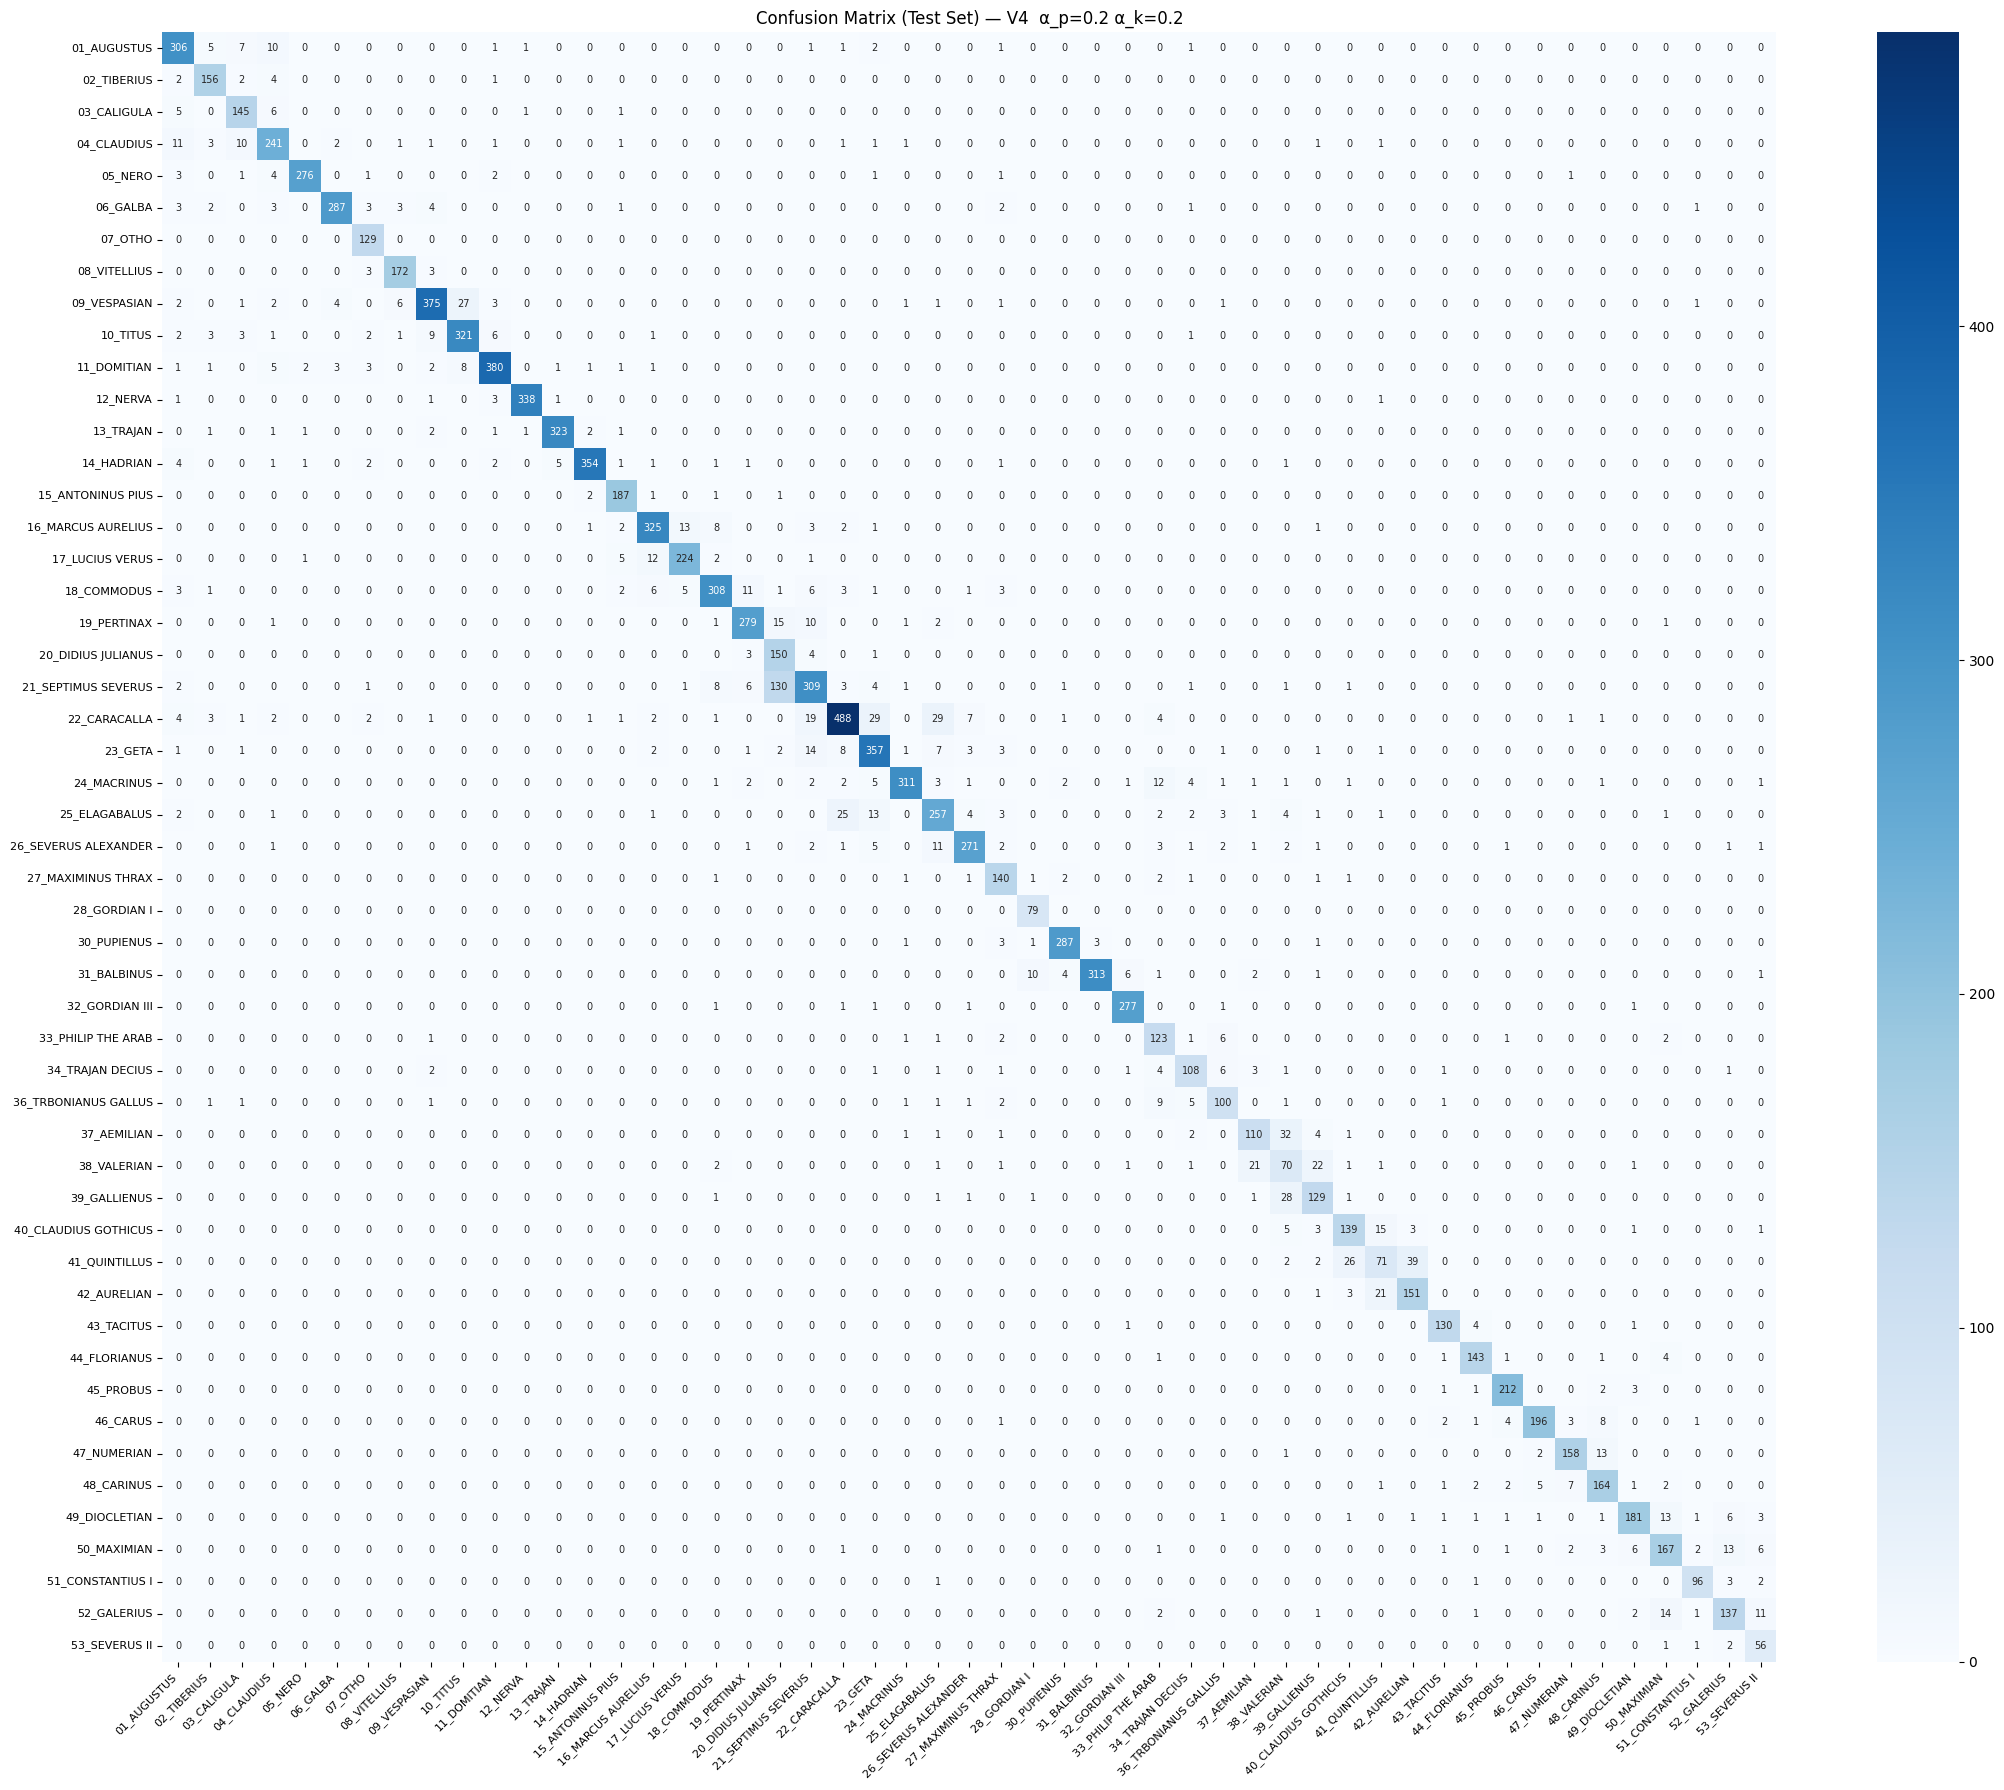

In [30]:
class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        targets = targets.to(device)
        preds   = fused_predict(feats, best_ap, best_ak).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — V4  α_p={best_ap} α_k={best_ak}')
plt.tight_layout()
plt.show()

In [31]:
TOP_CONFUSIONS = 3
total_correct  = int(cm.diagonal().sum())
total          = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct / total:.4f}')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
for i in np.argsort(row_acc):
    n_total   = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc       = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total}  acc={acc:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  → {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  → other: {remaining}')

Overall test accuracy: 11006/12427 = 0.8857

41_QUINTILLUS: 71/140  acc=0.507
  → 42_AURELIAN: 39 (27.9%)
  → 40_CLAUDIUS GOTHICUS: 26 (18.6%)
  → 38_VALERIAN: 2 (1.4%)
  → other: 2

38_VALERIAN: 70/122  acc=0.574
  → 39_GALLIENUS: 22 (18.0%)
  → 37_AEMILIAN: 21 (17.2%)
  → 18_COMMODUS: 2 (1.6%)
  → other: 7

21_SEPTIMUS SEVERUS: 309/469  acc=0.659
  → 20_DIDIUS JULIANUS: 130 (27.7%)
  → 18_COMMODUS: 8 (1.7%)
  → 19_PERTINAX: 6 (1.3%)
  → other: 16

37_AEMILIAN: 110/152  acc=0.724
  → 38_VALERIAN: 32 (21.1%)
  → 39_GALLIENUS: 4 (2.6%)
  → 34_TRAJAN DECIUS: 2 (1.3%)
  → other: 4

39_GALLIENUS: 129/163  acc=0.791
  → 38_VALERIAN: 28 (17.2%)
  → 18_COMMODUS: 1 (0.6%)
  → 25_ELAGABALUS: 1 (0.6%)
  → other: 4

25_ELAGABALUS: 257/321  acc=0.801
  → 22_CARACALLA: 25 (7.8%)
  → 23_GETA: 13 (4.0%)
  → 26_SEVERUS ALEXANDER: 4 (1.2%)
  → other: 22

36_TRBONIANUS GALLUS: 100/124  acc=0.806
  → 33_PHILIP THE ARAB: 9 (7.3%)
  → 34_TRAJAN DECIUS: 5 (4.0%)
  → 27_MAXIMINUS THRAX: 2 (1.6%)
  → other: 8

## Hierarchical classifier — Experiment #10

Stage 1 predicts which *dynasty / period* the coin belongs to (9 groups). This is a much easier problem and should hit >98 % accuracy. Stage 2 uses that prediction as a soft mask over the emperor probabilities: emperors outside the predicted period get down-weighted, reducing cross-period confusions like SEPTIMIUS SEVERUS → DIDIUS JULIANUS.

Final prediction blends the flat ensemble result with the dynasty-guided result.

In [32]:
DYNASTIES = {
    'JULIO_CLAUDIAN': ['AUGUSTUS', 'TIBERIUS', 'CALIGULA', 'CLAUDIUS', 'NERO'],
    'YEAR_OF_FOUR':   ['GALBA', 'OTHO', 'VITELLIUS'],
    'FLAVIAN':        ['VESPASIAN', 'TITUS', 'DOMITIAN'],
    'NERVA_ANTONINE': ['NERVA', 'TRAJAN', 'HADRIAN', 'ANTONINUS PIUS',
                       'MARCUS AURELIUS', 'LUCIUS VERUS'],
    'COMMODUS_CHAOS': ['COMMODUS', 'PERTINAX', 'DIDIUS JULIANUS'],
    'SEVERAN':        ['SEPTIMUS SEVERUS', 'CARACALLA', 'GETA', 'MACRINUS',
                       'ELAGABALUS', 'SEVERUS ALEXANDER'],
    'CRISIS_EARLY':   ['MAXIMINUS THRAX', 'GORDIAN I', 'PUPIENUS', 'BALBINUS',
                       'GORDIAN III', 'PHILIP THE ARAB', 'TRAJAN DECIUS',
                       'TRBONIANUS GALLUS', 'AEMILIAN'],
    'CRISIS_LATE':    ['VALERIAN', 'GALLIENUS', 'CLAUDIUS GOTHICUS', 'QUINTILLUS',
                       'AURELIAN', 'TACITUS', 'FLORIANUS', 'PROBUS',
                       'CARUS', 'NUMERIAN', 'CARINUS'],
    'TETRARCHY':      ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
}

dynasty_names   = sorted(DYNASTIES.keys())
dynasty_encoder = {d: i for i, d in enumerate(dynasty_names)}
emperor_to_dynasty = {e: d for d, emps in DYNASTIES.items() for e in emps}

# Map emperor index → dynasty index (fallback to first dynasty if somehow missing)
dynasty_of = torch.tensor(
    [dynasty_encoder.get(emperor_to_dynasty.get(idx_to_label[i], ''), 0)
     for i in range(num_classes)], dtype=torch.long
)
n_dynasties = len(dynasty_names)

def to_dynasty(emp_labs):
    return dynasty_of[emp_labs]

train_dyn_loader = DataLoader(
    TensorDataset(train_feats, to_dynasty(train_labs)),
    batch_size=512, sampler=train_sampler)
val_dyn_loader   = DataLoader(
    TensorDataset(val_feats,  to_dynasty(val_labs)),
    batch_size=512, shuffle=False)

print(f'{n_dynasties} dynasties:')
for i, d in enumerate(dynasty_names):
    print(f'  {i}: {d}  ({len(DYNASTIES[d])} emperors)')

9 dynasties:
  0: COMMODUS_CHAOS  (3 emperors)
  1: CRISIS_EARLY  (9 emperors)
  2: CRISIS_LATE  (11 emperors)
  3: FLAVIAN  (3 emperors)
  4: JULIO_CLAUDIAN  (5 emperors)
  5: NERVA_ANTONINE  (6 emperors)
  6: SEVERAN  (6 emperors)
  7: TETRARCHY  (5 emperors)
  8: YEAR_OF_FOUR  (3 emperors)


In [33]:
torch.manual_seed(42)
stage1 = nn.Sequential(
    nn.LayerNorm(feat_dim),
    nn.Linear(feat_dim, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, n_dynasties),
).to(device)

opt1   = torch.optim.AdamW(stage1.parameters(), lr=3e-4, weight_decay=1e-2)
sched1 = make_scheduler(opt1, 60 * len(train_dyn_loader),
                         warmup_steps=2 * len(train_dyn_loader))

best_dyn_acc, best_dyn_state = 0.0, None
for epoch in range(1, 61):
    stage1.train()
    for feats, dyn_targets in train_dyn_loader:
        feats, dyn_targets = feats.to(device), dyn_targets.to(device)
        opt1.zero_grad()
        F.cross_entropy(stage1(feats), dyn_targets).backward()
        opt1.step(); sched1.step()

    stage1.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for feats, dyn_targets in val_dyn_loader:
            feats, dyn_targets = feats.to(device), dyn_targets.to(device)
            correct += (stage1(feats).argmax(-1) == dyn_targets).sum().item()
            total   += dyn_targets.size(0)
    acc = correct / total
    if acc > best_dyn_acc:
        best_dyn_acc  = acc
        best_dyn_state = copy.deepcopy(stage1.state_dict())
    if epoch % 10 == 0:
        print(f'  ep {epoch:2d}/60  val dynasty acc={acc:.4f}')

stage1.load_state_dict(best_dyn_state)
stage1.eval()
print(f'Best dynasty val acc: {best_dyn_acc:.4f}')

  ep 10/60  val dynasty acc=0.9088
  ep 20/60  val dynasty acc=0.9266
  ep 30/60  val dynasty acc=0.9309
  ep 40/60  val dynasty acc=0.9394
  ep 50/60  val dynasty acc=0.9398
  ep 60/60  val dynasty acc=0.9416
Best dynasty val acc: 0.9416


In [34]:
# Soft dynasty mask: dynasty_mask[d, c] = True if emperor c belongs to dynasty d
dynasty_mask = torch.zeros(n_dynasties, num_classes, dtype=torch.float, device=device)
for dyn, emps in DYNASTIES.items():
    d_idx = dynasty_encoder[dyn]
    for e in emps:
        if e in label_encoder:
            dynasty_mask[d_idx, label_encoder[e]] = 1.0


@torch.no_grad()
def hierarchical_predict(feats, ap=best_ap, ak=best_ak, hier_weight=0.3):
    """Blend flat prediction with a dynasty-guided re-ranking.

    The dynasty classifier outputs a distribution over 9 periods.
    We use that as a soft mask over emperor logits — emperors outside
    the predicted period are down-weighted proportionally.
    """
    flat       = fused_predict(feats, ap, ak)              # (B, C)
    dyn_probs  = F.softmax(stage1(feats.to(device)), dim=-1)   # (B, D)
    soft_mask  = dyn_probs @ dynasty_mask                   # (B, C)
    soft_mask  = soft_mask / (soft_mask.sum(dim=-1, keepdim=True) + 1e-8)
    guided     = flat * soft_mask
    guided     = guided / (guided.sum(dim=-1, keepdim=True) + 1e-8)
    return (1 - hier_weight) * flat + hier_weight * guided


print('Sweeping hier_weight on val set...')
best_hw, best_hw_acc = 0.0, 0.0
for hw in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    correct, total = 0, 0
    for feats, targets in val_loader:
        targets = targets.to(device)
        probs   = hierarchical_predict(feats, hier_weight=hw)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'  hier_weight={hw:.1f}  val acc={acc:.4f}')
    if acc > best_hw_acc:
        best_hw_acc = acc; best_hw = hw

print(f'\nBest hier_weight: {best_hw}  val={best_hw_acc:.4f}')

Sweeping hier_weight on val set...
  hier_weight=0.0  val acc=0.8827
  hier_weight=0.1  val acc=0.8835
  hier_weight=0.2  val acc=0.8844
  hier_weight=0.3  val acc=0.8845
  hier_weight=0.4  val acc=0.8841
  hier_weight=0.5  val acc=0.8839

Best hier_weight: 0.3  val=0.8845


In [35]:
print('=== FINAL V4 RESULTS ===')
print('\n--- Flat fusion only ---')
for name, loader in [('Val  ', val_loader), ('Test ', test_loader)]:
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        correct += (fused_predict(feats, best_ap, best_ak).argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    print(f'  {name}: {correct / total:.4f}  ({correct}/{total})')

print(f'\n--- Flat + hierarchical (hier_weight={best_hw}) ---')
for name, loader in [('Val  ', val_loader), ('Test ', test_loader)]:
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        correct += (hierarchical_predict(feats, hier_weight=best_hw).argmax(-1)
                    == targets).sum().item()
        total   += targets.size(0)
    print(f'  {name}: {correct / total:.4f}  ({correct}/{total})')

=== FINAL V4 RESULTS ===

--- Flat fusion only ---
  Val  : 0.8827  (8776/9942)
  Test : 0.8857  (11006/12427)

--- Flat + hierarchical (hier_weight=0.3) ---
  Val  : 0.8845  (8794/9942)
  Test : 0.8869  (11022/12427)


## Backbone fine-tuning — Experiment #5 (optional)

Unfreeze the last 2 transformer blocks of C-RADIO and fine-tune end-to-end using a 2-LR setup: backbone at `1e-5`, head at `3e-4`. Run this **after** the ensemble is trained and saved, as it requires keeping the full backbone in memory (~4 GB extra VRAM). Re-extracts embeddings on-the-fly per batch.

Expected gain: 1–3 % over the frozen-backbone result.

In [19]:
# ---- Config ----
FINETUNE_EPOCHS = 20
FINETUNE_BATCH  = 16    # smaller batch due to full-backbone memory
UNFREEZE_BLOCKS = 2     # last N transformer blocks


class CoinFinetuneDataset(Dataset):
    """Loads images with random TTA augmentation for end-to-end fine-tuning."""
    TRAIN_RES = 256   # all outputs normalised to this so batches can be stacked
    AUGS = [
        (256, False,   0), (256, True,   0),
        (256, False,  90), (384, False,  0),
        (384, True,   0),  (384, False, 90),
    ]

    def __init__(self, fps, labs):
        self.fps = fps; self.labs = labs

    def __len__(self): return len(self.fps)

    def __getitem__(self, i):
        res, flip, rot = self.AUGS[np.random.randint(len(self.AUGS))]
        img = Image.open(self.fps[i]).convert('RGB')
        img = img.resize((res, res), Image.BILINEAR)
        if flip: img = img.transpose(Image.FLIP_LEFT_RIGHT)
        if rot:  img = img.rotate(rot, expand=False)
        # Normalise to a fixed output size so all tensors in a batch share shape.
        if res != self.TRAIN_RES:
            img = img.resize((self.TRAIN_RES, self.TRAIN_RES), Image.BILINEAR)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


# all_labs is already merged and re-encoded (0..num_classes-1) by cell-7.
# filepaths was extracted in the same sorted order, so all_labs[i] ↔ filepaths[i].
all_fps  = [str(p) for p in filepaths]
ft_labs  = all_labs   # shape (N,), values 0..num_classes-1

assert ft_labs.max() < num_classes, (
    f"Label out of range: max={ft_labs.max()} but num_classes={num_classes}")

idx_all = np.arange(len(all_fps))
idx_tr_te, idx_test = train_test_split(idx_all, test_size=0.2,
                                        stratify=ft_labs.numpy(), random_state=42)
idx_train, idx_val  = train_test_split(idx_tr_te, test_size=0.2,
                                        stratify=ft_labs[idx_tr_te].numpy(), random_state=42)

ft_train_ds = CoinFinetuneDataset([all_fps[i] for i in idx_train],
                                   ft_labs[idx_train].tolist())
ft_val_ds   = CoinFinetuneDataset([all_fps[i] for i in idx_val],
                                   ft_labs[idx_val].tolist())
ft_train_loader = DataLoader(ft_train_ds, batch_size=FINETUNE_BATCH,
                              shuffle=True, num_workers=4, pin_memory=True)
ft_val_loader   = DataLoader(ft_val_ds,   batch_size=FINETUNE_BATCH,
                              shuffle=False, num_workers=4, pin_memory=True)

print(f'Fine-tune train: {len(ft_train_ds)}  val: {len(ft_val_ds)}  num_classes: {num_classes}')

Fine-tune train: 39765  val: 9942  num_classes: 51


In [20]:
print('Loading C-RADIO v4-H for fine-tuning...')
radio_ft = torch.hub.load('NVlabs/RADIO', 'radio_model',
                           version='c-radio_v4-h', progress=True)
radio_ft = radio_ft.to(device)

# Freeze all params first
for p in radio_ft.parameters():
    p.requires_grad = False

# Unfreeze last UNFREEZE_BLOCKS transformer blocks
# C-RADIO ViT-H blocks are in radio_ft.model.blocks
backbone_blocks = list(radio_ft.model.blocks)
for blk in backbone_blocks[-UNFREEZE_BLOCKS:]:
    for p in blk.parameters():
        p.requires_grad = True

n_trainable_bb = sum(p.numel() for p in radio_ft.parameters() if p.requires_grad)
print(f'Unfroze last {UNFREEZE_BLOCKS} blocks — {n_trainable_bb/1e6:.1f}M trainable backbone params')

# Fresh single head for fine-tuning (starts from scratch to avoid bias)
# Input dim: 2560 (summary) + 2560 (patch) is not available here since we run live.
# Use summary-only (2560-d) for the fine-tuning head.
ft_head = CoinHeadV4(2560, num_classes, hidden=2048, dropout=0.3).to(device)

optimizer_ft = torch.optim.AdamW([
    {'params': [p for p in radio_ft.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': ft_head.parameters(), 'lr': 3e-4},
], weight_decay=1e-2)

steps_ft    = FINETUNE_EPOCHS * len(ft_train_loader)
scheduler_ft = make_scheduler(optimizer_ft, steps_ft,
                               warmup_steps=len(ft_train_loader))

best_ft_acc, best_ft_state = 0.0, (None, None)

for epoch in range(1, FINETUNE_EPOCHS + 1):
    radio_ft.train(); ft_head.train()
    running = 0.0
    for imgs, targets in ft_train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer_ft.zero_grad()
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, _ = radio_ft(imgs)
        logits = ft_head(summary.float(), targets)
        loss   = F.cross_entropy(logits, targets, weight=cb_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(radio_ft.parameters()) + list(ft_head.parameters()), 1.0)
        optimizer_ft.step(); scheduler_ft.step()
        running += loss.item()

    radio_ft.eval(); ft_head.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, targets in ft_val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                summary, _ = radio_ft(imgs)
            correct += (ft_head(summary.float()).argmax(-1) == targets).sum().item()
            total   += targets.size(0)
    acc = correct / total
    if acc > best_ft_acc:
        best_ft_acc  = acc
        best_ft_state = (copy.deepcopy(radio_ft.state_dict()),
                         copy.deepcopy(ft_head.state_dict()))
    print(f'[finetune] ep {epoch:2d}/{FINETUNE_EPOCHS}  '
          f'loss {running / len(ft_train_loader):.4f}  '
          f'val {acc:.4f}' + (' <--' if acc >= best_ft_acc else ''))

torch.save({'radio': best_ft_state[0], 'head': best_ft_state[1]},
           'emp_model_v4_finetuned.pth')
print(f'\nBest fine-tune val acc: {best_ft_acc:.4f}')
print('Saved → emp_model_v4_finetuned.pth')

del radio_ft
torch.cuda.empty_cache()

Loading C-RADIO v4-H for fine-tuning...


Using cache found in /home/david/.cache/torch/hub/NVlabs_RADIO_main
/home/david/.cache/torch/hub/NVlabs_RADIO_main/hubconf.py:80: UserWarning: Unexpected keys in state dict: ['patch_generator._vis_cond.norm_mean', 'patch_generator._vis_cond.norm_std']
  warnings.warn(f'Unexpected keys in state dict: {key_warn.unexpected_keys}')


Unfroze last 2 blocks — 39.4M trainable backbone params
[finetune] ep  1/20  loss 4.0505  val 0.7631 <--
[finetune] ep  2/20  loss 2.1375  val 0.8229 <--
[finetune] ep  3/20  loss 1.6795  val 0.8366 <--
[finetune] ep  4/20  loss 1.4132  val 0.8511 <--
[finetune] ep  5/20  loss 1.1945  val 0.8546 <--
[finetune] ep  6/20  loss 1.0321  val 0.8652 <--
[finetune] ep  7/20  loss 0.8822  val 0.8669 <--
[finetune] ep  8/20  loss 0.7621  val 0.8785 <--
[finetune] ep  9/20  loss 0.6770  val 0.8805 <--
[finetune] ep 10/20  loss 0.5865  val 0.8870 <--
[finetune] ep 11/20  loss 0.5115  val 0.8858
[finetune] ep 12/20  loss 0.4399  val 0.8916 <--
[finetune] ep 13/20  loss 0.3885  val 0.8901
[finetune] ep 14/20  loss 0.3354  val 0.8972 <--
[finetune] ep 15/20  loss 0.3153  val 0.8918
[finetune] ep 16/20  loss 0.2848  val 0.8913
[finetune] ep 17/20  loss 0.2663  val 0.8916
[finetune] ep 18/20  loss 0.2454  val 0.8945
[finetune] ep 19/20  loss 0.2376  val 0.8911
[finetune] ep 20/20  loss 0.2304  val 0.8